# Neural networks with NumPy only

This notebook is a from-scratch introduction for students who want to see how a neural network actually learns without using Keras or PyTorch.

We will build a small neural network using only `numpy` and go through the important steps explicitly:

- data and shapes,
- parameter initialization,
- forward pass,
- loss,
- backpropagation,
- learning rate,
- gradient descent updates.

The focus is practical understanding, not heavy math notation.

## Problem setup

We will train a tiny neural network to solve the XOR problem.

Why XOR?

- it is very small,
- the inputs are easy to inspect,
- a model with no hidden layer cannot solve it well,
- a small neural network with a hidden layer can solve it.

That makes it a good teaching example.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
np.random.seed(42)

In [ ]:
X = np.array([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0]
])

y = np.array([[0.0], [1.0], [1.0], [0.0]])

print("Input shape:", X.shape)
print("Target shape:", y.shape)
print("\nX:\n", X)
print("\ny:\n", y)

## Shapes matter

In NumPy implementations, many bugs come from shape mismatches.

Here:

- `X` has shape `(4, 2)` because we have 4 training examples and 2 input features,
- `y` has shape `(4, 1)` because each example has one target value.

We will build a network with:

- 2 input units,
- 3 hidden units,
- 1 output unit.

## Network architecture

Our network will look like this:

`input (2) -> hidden (3) -> output (1)`

We will use:

- `tanh` in the hidden layer,
- `sigmoid` in the output layer.

Why `sigmoid` at the end?

Because XOR is a binary classification problem, so we want one probability-like output between 0 and 1.

In [6]:
input_size = 2
hidden_size = 3
output_size = 1

W1 = np.random.randn(input_size, hidden_size) * 0.5
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.5
b2 = np.zeros((1, output_size))

print("W1 shape:", W1.shape)
print("b1 shape:", b1.shape)
print("W2 shape:", W2.shape)
print("b2 shape:", b2.shape)

W1 shape: (2, 3)
b1 shape: (1, 3)
W2 shape: (3, 1)
b2 shape: (1, 1)


In [9]:
W1.T

array([[ 0.2484,  0.7615],
       [-0.0691, -0.1171],
       [ 0.3238, -0.1171]])

## Parameter initialization

The parameters are:

- `W1`, `b1` for the first layer,
- `W2`, `b2` for the second layer.

Practical rules:

- weights usually start as small random numbers,
- biases often start at zero,
- if all weights started identical, neurons in the same layer would learn the same thing.

That is why random initialization matters.

In [7]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def sigmoid_derivative(sigmoid_output):
    return sigmoid_output * (1 - sigmoid_output)


def tanh_derivative(tanh_output):
    return 1 - tanh_output ** 2

## Forward pass

In the forward pass, we compute predictions from left to right.

Layer 1:

- `Z1 = X @ W1 + b1`
- `A1 = tanh(Z1)`

Layer 2:

- `Z2 = A1 @ W2 + b2`
- `A2 = sigmoid(Z2)`

Interpretation:

- `Z` means the linear combination before activation,
- `A` means the activated output that moves to the next layer.

In [11]:
def forward_pass(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1
    A1 = np.tanh(Z1)
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)
    cache = {
        "X": X,
        "Z1": Z1,
        "A1": A1,
        "Z2": Z2,
        "A2": A2
    }
    return A2, cache

In [12]:
predictions, cache = forward_pass(X, W1, b1, W2, b2)

print("Hidden activations A1:\n", cache["A1"])
print("\nOutput predictions A2:\n", predictions)

Hidden activations A1:
 [[ 0.      0.      0.    ]
 [ 0.642  -0.1165 -0.1165]
 [ 0.2434 -0.069   0.313 ]
 [ 0.7657 -0.1841  0.2039]]

Output predictions A2:
 [[0.5   ]
 [0.62  ]
 [0.523 ]
 [0.6192]]


## Loss function

We need a number that tells us how wrong the model is.

For binary classification, a common choice is binary cross-entropy.

You do not need to memorize the full formula yet. The practical meaning is enough:

- if the model gives high probability to the correct answer, loss gets smaller,
- if the model is confidently wrong, loss gets larger.

Training is the process of adjusting weights to reduce this loss.

In [13]:
def binary_cross_entropy(y_true, y_pred):
    eps = 1e-8
    y_pred = np.clip(y_pred, eps, 1 - eps)
    loss = -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return np.mean(loss)


initial_loss = binary_cross_entropy(y, predictions)
print("Initial loss:", initial_loss)

Initial loss: 0.6961861606921318


## Backpropagation intuition

Backpropagation answers one question:

**How should each weight change to reduce the loss?**

The result of backprop is a set of gradients:

- `dW1`, `db1`,
- `dW2`, `db2`.

A gradient tells us the direction in which a parameter should move.

Practical interpretation:

- large positive gradient -> parameter is pushing loss upward,
- large negative gradient -> increasing the parameter may help,
- gradient near zero -> small immediate effect.

## Backpropagation steps in this network

We go from the output layer backward.

For this setup, the key chain is:

1. compute output error,
2. turn that into gradients for `W2` and `b2`,
3. pass the error back into the hidden layer,
4. compute gradients for `W1` and `b1`.

You do not need to derive every formula by hand to understand the workflow.

In [14]:
def backward_pass(y_true, cache, W2):
    X = cache["X"]
    A1 = cache["A1"]
    A2 = cache["A2"]

    m = X.shape[0]

    dZ2 = A2 - y_true
    dW2 = (A1.T @ dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * tanh_derivative(A1)
    dW1 = (X.T @ dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    grads = {
        "dW1": dW1,
        "db1": db1,
        "dW2": dW2,
        "db2": db2
    }
    return grads

In [15]:
grads = backward_pass(y, cache, W2)

for name, grad in grads.items():
    print(name)
    print(grad)
    print()

dW1
[[-0.038   0.0118 -0.0096]
 [ 0.0065  0.0214 -0.0128]]

db1
[[ 0.0166  0.0239 -0.0169]]

dW2
[[ 0.0285]
 [-0.0092]
 [ 0.0053]]

db2
[[0.0656]]



## Learning rate

The learning rate controls how large each parameter update is.

Update rule:

`parameter = parameter - learning_rate * gradient`

Practical consequences:

- learning rate too small -> training is very slow,
- learning rate too large -> training may jump around or diverge,
- a reasonable learning rate often matters as much as the architecture.

This is one of the first hyperparameters to tune.

In [16]:
learning_rate = 0.5

W1_new = W1 - learning_rate * grads["dW1"]
b1_new = b1 - learning_rate * grads["db1"]
W2_new = W2 - learning_rate * grads["dW2"]
b2_new = b2 - learning_rate * grads["db2"]

new_predictions, _ = forward_pass(X, W1_new, b1_new, W2_new, b2_new)
new_loss = binary_cross_entropy(y, new_predictions)

print("Loss before update:", initial_loss)
print("Loss after one update:", new_loss)

Loss before update: 0.6961861606921318
Loss after one update: 0.6921731604032868


## One training step

A full training step is:

1. forward pass,
2. compute loss,
3. backward pass,
4. update parameters.

Training means repeating this many times.

In [18]:
def train_step(X, y, W1, b1, W2, b2, learning_rate):
    predictions, cache = forward_pass(X, W1, b1, W2, b2)
    loss = binary_cross_entropy(y, predictions)
    grads = backward_pass(y, cache, W2)

    W1 = W1 - learning_rate * grads["dW1"]
    b1 = b1 - learning_rate * grads["db1"]
    W2 = W2 - learning_rate * grads["dW2"]
    b2 = b2 - learning_rate * grads["db2"]

    return W1, b1, W2, b2, loss

## Full training loop

Now we reset the parameters and train for many epochs.

An **epoch** means one full pass over the training data.

Since XOR has only 4 examples, one epoch is very small. The code is still the same pattern used in larger models.

In [19]:
import time
np.random.seed(42)

W1 = np.random.randn(input_size, hidden_size) * 0.5
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size) * 0.5
b2 = np.zeros((1, output_size))

learning_rate = 0.5
epochs = 500
loss_history = []

for epoch in range(epochs):
    W1, b1, W2, b2, loss = train_step(X, y, W1, b1, W2, b2, learning_rate)
    loss_history.append(loss)

    if epoch % 5 == 0:
        time.sleep(1)
        print(f"Epoch {epoch:4d} | loss = {loss:.6f}")

Epoch    0 | loss = 0.696186
Epoch    5 | loss = 0.683065
Epoch   10 | loss = 0.674993
Epoch   15 | loss = 0.666781
Epoch   20 | loss = 0.657844
Epoch   25 | loss = 0.647841
Epoch   30 | loss = 0.636494
Epoch   35 | loss = 0.623668
Epoch   40 | loss = 0.609424
Epoch   45 | loss = 0.594007
Epoch   50 | loss = 0.577757
Epoch   55 | loss = 0.561004
Epoch   60 | loss = 0.543961
Epoch   65 | loss = 0.526686
Epoch   70 | loss = 0.509081
Epoch   75 | loss = 0.490934
Epoch   80 | loss = 0.471987
Epoch   85 | loss = 0.452009
Epoch   90 | loss = 0.430869
Epoch   95 | loss = 0.408576
Epoch  100 | loss = 0.385293
Epoch  105 | loss = 0.361309
Epoch  110 | loss = 0.336995
Epoch  115 | loss = 0.312761
Epoch  120 | loss = 0.289014
Epoch  125 | loss = 0.266127
Epoch  130 | loss = 0.244413
Epoch  135 | loss = 0.224102
Epoch  140 | loss = 0.205340
Epoch  145 | loss = 0.188185
Epoch  150 | loss = 0.172629
Epoch  155 | loss = 0.158607
Epoch  160 | loss = 0.146021
Epoch  165 | loss = 0.134752
Epoch  170 | l

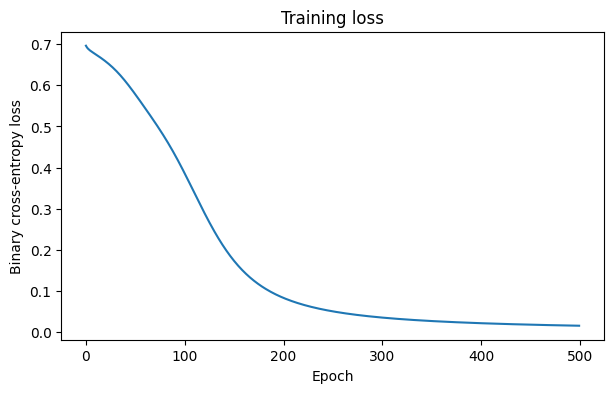

In [20]:
plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.title("Training loss")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.show()

In [21]:
final_predictions, _ = forward_pass(X, W1, b1, W2, b2)
predicted_classes = (final_predictions >= 0.5).astype(int)

print("Final probabilities:\n", final_predictions)
print("\nPredicted classes:\n", predicted_classes)
print("\nTrue classes:\n", y.astype(int))

Final probabilities:
 [[0.0029]
 [0.9837]
 [0.9823]
 [0.0233]]

Predicted classes:
 [[0]
 [1]
 [1]
 [0]]

True classes:
 [[0]
 [1]
 [1]
 [0]]


## Visual interpretation

Each output is the network's estimate that the class is 1.

For XOR we want:

- `[0, 0] -> 0`
- `[0, 1] -> 1`
- `[1, 0] -> 1`
- `[1, 1] -> 0`

If the final probabilities are close to those targets, the network has learned the pattern.

## Try different learning rates

The cell below trains the same model with several learning rates so you can compare convergence.

This is one of the most useful experiments for beginners because it makes the effect of the learning rate visible.

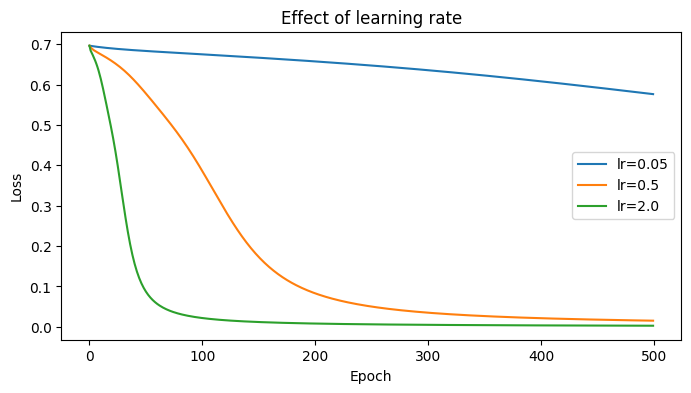

In [22]:
def train_model(learning_rate, epochs=500, seed=42):
    np.random.seed(seed)
    W1 = np.random.randn(input_size, hidden_size) * 0.5
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, output_size) * 0.5
    b2 = np.zeros((1, output_size))
    history = []

    for _ in range(epochs):
        W1, b1, W2, b2, loss = train_step(X, y, W1, b1, W2, b2, learning_rate)
        history.append(loss)

    return history


rates = [0.05, 0.5, 2.0]

plt.figure(figsize=(8, 4))
for rate in rates:
    history = train_model(rate)
    plt.plot(history, label=f"lr={rate}")

plt.title("Effect of learning rate")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Important ideas to remember

- A neural network is a sequence of matrix operations plus activation functions.
- The forward pass computes predictions.
- The loss measures how wrong those predictions are.
- Backpropagation computes gradients for every parameter.
- The learning rate controls update size.
- Gradient descent repeats small updates until the loss becomes smaller.

That is the core training loop behind much larger neural networks too.

## Exercises

1. Change `hidden_size` from 3 to 2 and then to 5. What changes?
2. Try learning rates `0.01`, `0.1`, `1.0`, and `5.0`.
3. Print the values of `W1` and `W2` before and after training.
4. Replace `tanh` in the hidden layer with a sigmoid activation and compare learning.
5. Add a second hidden layer and extend the forward and backward pass yourself.

If you can do exercises 1 to 4, you already understand the essential mechanics of neural-network training.